## 강원도 지자체별 신재생에너지 데이터 분석

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [20]:
#기상데이터, 에너지 데이터 불러오기
rain = pd.read_parquet("./weather_rain.parquet")
temp = pd.read_parquet("./weather_temp.parquet")
wind = pd.read_parquet("./weather_wind.parquet")
sun = pd.read_parquet("./weather_sun.parquet")


In [ ]:
#DF 값의 구역 컬럼명은 관측소로 인식. parquet 원본은 건들지 않는다. 
rain = rain.rename(columns={"구역": "station"})

In [4]:
#관측지점과 행정구역 대응되도록 명시적 테이블화

admin_weather_map = pd.DataFrame({
    "admin_region": [
        "강릉시", "강릉시",  # 추가
        "고성군", "동해시", "삼척시", "속초시",
        "양양군", "영월군", "원주시", "인제군",
        "정선군", "철원군", "춘천시", "춘천시",  # 추가
        "태백시", "평창군", "홍천군", "횡성군"
    ],
    "station": [
        "강릉", "북강릉",   # 추가
        "속초", "동해", "동해", "속초",
        "속초", "영월", "원주", "인제",
        "정선군", "철원", "북춘천", "춘천",  # 추가
        "태백", "대관령", "홍천", "원주"
    ]
})

#행정구역 - 관측소 매핑 적용 코드
# 기상 컬럼 '구역' 행에 맞춰서 admin_region(행정구역)컬럼 정보를 붙인다.(병합)
rain = rain.merge(
    admin_weather_map,
    on="station",
    how="left"
)

#행정구역 단위로 다시 묶어 정리하기. 그러지 않으면 동일 기상값이 여러번 계산된다.
rain_admin = (
    rain
    .groupby(["admin_region", "연도", "월"], as_index=False)
    .mean(numeric_only=True)
)

#매핑 누락있는지 확인하는 코드
rain[rain["admin_region"].isna()]["station"].unique()

array([], dtype=object)

In [53]:
# 엑셀 원본 데이터 불러오기
# 원본 엑셀에서 필요한 정보만 추출해 상관 분석을 하고자 함.

path = "../data/processed/강원도_신재생에너지_통합_2019-2023_R.xlsx"

xls = pd.ExcelFile(path)

energy_sheets = [
    s for s in xls.sheet_names
    if s.startswith("(발전량)")
]

energy_sheets #필요한 정보만 선별 됐는지 확인.

['(발전량) 2019년_강원',
 '(발전량) 2020년_강원',
 '(발전량) 2021년_강원',
 '(발전량) 2022년_강원',
 '(발전량) 2023년_강원']

In [ ]:
# 시트 내에서 특정 컬럼- 결과값을 추출하기 위한 함수

def load_energy_sheet(path, sheet_name):
    # 연도 추출
    year = int(sheet_name[5:9])  # '(발전량)2019년_강원'

    df = pd.read_excel(path, sheet_name=sheet_name)

    # 컬럼 선택
    df = df[[
        df.columns[0],  # 행정구역
        "태양광",
        "풍력",
        "수력",
        "바이오"
    ]]

    df = df.rename(columns={
        df.columns[0]: "admin_region"
    })

    df["연도"] = year

    # 숫자 정제
    for col in ["태양광", "풍력", "수력", "바이오"]:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", "")
            .replace("-", np.nan)
            .astype(float)
        )

    # 숫자 변환하고 나서 return 하기 전에 수정
    # 소수점 두 자리로 반올림
    df[["태양광", "풍력", "수력", "바이오"]] = (
        df[["태양광", "풍력", "수력", "바이오"]]
        .round(2) #소수점 두 자리까지, NaN은 유지된다.
    )

    return df

#발전량 수치는 시각적 가독성을 고려해 두자리 수까지 표시, 반올림해 제시했다.
#통계 분석에는 원본의 정밀 데이터를 사용.

In [12]:
#원본 자료의 컬럼이 행2까지 들어가는 걸 파악해 구조 파악으로 코드 입력
df_test = pd.read_excel(path, sheet_name=energy_sheets[0], header=None)
df_test.head(10)

,0,1,2,3,4,5,6,7,8,9,...,64,65,66,67,68,69,70,71,72,73
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,신에너지,NaN,NaN,NaN,NaN
1,NaN,신·재생에너지 총발전량(MWh),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,연료전지,,,IGCC,NaN
2,NaN,NaN,NaN,NaN,NaN,재생에너지,NaN,NaN,신에너지,NaN,...,NaN,시멘트킬른보조연료,NaN,정제연료유,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,사업용,자가용,NaN,합계,사업용,자가용,합계,사업용,...,자가용,NaN,자가용,NaN,사업용,NaN,사업용,자가용,NaN,사업용
4,강원,3675820.950698,3601066.113159,74754.83754,NaN,3674888.969924,3600329.116159,74559.853765,931.980774,736.997,...,0,0,0,0,0,931.980774,736.997,194.983774,0,0
5,춘천시,595936.040423,587308.297752,8627.742671,NaN,595781.291396,587308.297752,8472.993644,154.749027,0,...,0,0,0,0,0,154.749027,0,154.749027,0,0
6,원주시,145015.244078,134803.235935,10212.008143,NaN,145015.244078,134803.235935,10212.008143,0,0,...,0,0,0,0,0,0,0,0,0,0
7,강릉시,1006797.126619,997613.470804,9183.655815,NaN,1006797.126619,997613.470804,9183.655815,0,0,...,0,0,0,0,0,0,0,0,0,0
8,동해시,351457.142062,348888.00263,2569.139432,NaN,351457.142062,348888.00263,2569.139432,0,0,...,0,0,0,0,0,0,0,0,0,0
9,태백시,141568.077575,140246.822872,1321.254703,NaN,141568.077575,140246.822872,1321.254703,0,0,...,0,0,0,0,0,0,0,0,0,0


In [54]:
# 시트 내에서 특정 컬럼- 결과값을 추출하기 위한 함수 개선
import re
import numpy as np
import pandas as pd

def load_energy_sheet(path, sheet_name):
    # 연도 추출
    year = int(re.search(r"\d{4}", sheet_name).group())

    df = pd.read_excel(
        path,
        sheet_name=sheet_name,
        header=1
    )

    # 컬럼명 정리
    df.columns = df.columns.str.strip()

    # 행정구역 컬럼명 통일
    df = df.rename(columns={df.columns[0]: "admin_region"})

    # 설명 행 제거
    df = df[df["admin_region"].notna()]

    # 행정구역 문자열 정리
    df["admin_region"] = (
        df["admin_region"]
        .astype(str)
        .str.strip()
    )

    # 불필요한 행 제거
    exclude_regions = ["강원", "기타"]
    df = df[~df["admin_region"].isin(exclude_regions)]

    # 필수 컬럼 체크
    required_cols = ["태양광", "풍력", "수력", "바이오"]
    missing = set(required_cols) - set(df.columns)
    if missing:
        raise ValueError(f"{sheet_name}에 컬럼 없음: {missing}")

    # 필요한 컬럼만 선택
    df = df[["admin_region"] + required_cols]

    # 연도 추가
    df["연도"] = year

    # 숫자 정제
    for col in required_cols:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", "")
            .replace("-", np.nan)
            .astype(float)
            .round(2)
        )

    return df
#발전량 수치는 시각적 가독성을 고려해 두자리 수까지 표시, 반올림해 제시했다.
#통계 분석에는 원본의 정밀 데이터를 사용.

In [ ]:
energy_dfs = [load_energy_sheet(path, s) for s in energy_sheets]
energy_all = pd.concat(energy_dfs, ignore_index=True)

energy_all.head()
energy_all["연도"].unique()

#연도가 제대로 출력됐는지 확인. 

array([2019, 2020, 2021, 2022, 2023])

In [58]:
# 데이터 확인

test_df = load_energy_sheet(path, energy_sheets[0])
test_df.head()

,admin_region,태양광,풍력,수력,바이오,연도
3,춘천시,63813.15,0.00,523022.67,4748.10,2019
4,원주시,83328.75,0.00,0.00,8327.00,2019
5,강릉시,75431.17,87820.34,1251.87,842293.74,2019
6,동해시,17413.28,0.00,21230.19,312813.67,2019
7,태백시,20581.02,120937.89,0.00,0.00,2019


In [ ]:
test_df = load_energy_sheet(path, energy_sheets[0])

test_df.head()
test_df["연도"].unique()
test_df.dtypes

#admin은 문자열 나머지는 float64로 나와야 정상 출력.

admin_region     object
태양광             float64
풍력              float64
수력              float64
바이오             float64
연도                int64
dtype: object

엑셀 원본 데이터는 컬럼이 여러 행에서 작성되었기에 불필요한 요소를 제거하고 수치형 데이터를 정제했다.

상관관계 분석하기 앞서 기상 데이터는 20-25년도 월별 데이터, 발전량은 19-23년도 연간 데이터이므로
월별 기상 데이터를 연도로 집계(sum/mean)해 20-23년도로 필터하고
에너지 발전량을 행정구역과 연도 기준으로 병합해 사용하고자 한다. 

In [21]:
#위에 작성한 코드는 rian 데이터만 매핑 처리했기에 다른 기상데이터에 활용 가능한 함수 생성

def weather_admin_monthly(df, admin_weather_map):
    """
    df: weather parquet 로드한 원본 DF
    admin_weather_map: station → admin_region 매핑 DF
    """
    # 관측소 컬럼 통일
    df = df.rename(columns={"구역": "station"})

    # 행정구역 매핑
    df = df.merge(
        admin_weather_map,
        on="station",
        how="left"
    )

    # 행정구역 · 연도 · 월 단위로 집계
    df_admin = (
        df
        .groupby(["admin_region", "연도", "월"], as_index=False)
        .mean(numeric_only=True)
    )

    return df_admin

In [22]:
#함수를 사용해 처리.

rain_admin = weather_admin_monthly(rain, admin_weather_map)
temp_admin = weather_admin_monthly(temp, admin_weather_map)
wind_admin = weather_admin_monthly(wind, admin_weather_map)
sun_admin  = weather_admin_monthly(sun,  admin_weather_map)

In [ ]:
#매핑 누락이 있는지 확인

for name, df in {
    "rain": rain_admin,
    "temp": temp_admin,
    "wind": wind_admin,
    "sun": sun_admin
}.items():
    missing = df[df["admin_region"].isna()]
    if len(missing) > 0:
        print(f"{name} 누락 관측소:", missing["station"].unique())

#모든 기상 데이터를 동일한 행정구역–관측소 매핑 기준을 적용하여 행정구역,연도,월 단위로 정규화

In [31]:
rain_admin


,admin_region,연도,월,지점번호,강수량_mm,일최다강수량_mm
0,강릉시,2020,1,104.5,105.10,49.45
1,강릉시,2020,2,104.5,74.10,42.60
2,강릉시,2020,3,104.5,47.95,18.40
3,강릉시,2020,4,104.5,67.05,23.15
4,강릉시,2020,5,104.5,103.50,32.80
...,...,...,...,...,...,...
1147,횡성군,2025,8,114.0,110.90,67.60
1148,횡성군,2025,9,114.0,274.20,73.70
1149,횡성군,2025,10,114.0,155.90,50.30
1150,횡성군,2025,11,114.0,15.10,7.50


In [32]:
temp_admin

,admin_region,연도,월,지점번호,평균기온_C,평균최고기온_C,최고기온_C,평균최저기온_C,최저기온_C
0,강릉시,2020,1,104.5,3.95,7.75,11.55,0.90,-4.30
1,강릉시,2020,2,104.5,4.55,9.15,16.65,0.30,-7.55
2,강릉시,2020,3,104.5,8.35,13.35,20.55,3.15,-0.95
3,강릉시,2020,4,104.5,11.30,16.10,26.30,6.40,0.85
4,강릉시,2020,5,104.5,17.65,22.40,32.35,13.55,7.75
...,...,...,...,...,...,...,...,...,...
1147,횡성군,2025,8,114.0,27.50,32.20,36.00,23.80,18.30
1148,횡성군,2025,9,114.0,22.40,27.40,33.40,18.80,14.20
1149,횡성군,2025,10,114.0,15.90,20.80,26.90,12.10,-0.50
1150,횡성군,2025,11,114.0,7.10,13.60,19.70,1.60,-4.70


In [30]:
wind_admin

,admin_region,연도,월,지점번호,평균풍속_ms,최대풍속_ms,최대풍속풍향_deg,최대순간풍속_ms,최대순간풍속풍향_deg
0,강릉시,2020,1,104.5,2.25,7.50,275.0,14.10,275.0
1,강릉시,2020,2,104.5,2.40,9.45,250.0,17.90,260.0
2,강릉시,2020,3,104.5,2.35,10.95,250.0,22.60,260.0
3,강릉시,2020,4,104.5,2.55,9.15,250.0,17.95,250.0
4,강릉시,2020,5,104.5,2.05,8.15,295.0,17.45,270.0
...,...,...,...,...,...,...,...,...,...
1147,횡성군,2025,8,114.0,1.30,4.90,270.0,12.30,320.0
1148,횡성군,2025,9,114.0,1.20,8.20,290.0,17.40,320.0
1149,횡성군,2025,10,114.0,1.10,5.50,270.0,10.00,320.0
1150,횡성군,2025,11,114.0,1.10,5.30,270.0,10.40,270.0


In [29]:
sun_admin

,admin_region,연도,월,지점번호,일조합_hr,일조율_pct
0,강릉시,2020,1,104.5,157.80,51.500
1,강릉시,2020,2,104.5,198.10,63.270
2,강릉시,2020,3,104.5,254.75,68.575
3,강릉시,2020,4,104.5,242.20,61.160
4,강릉시,2020,5,104.5,220.25,49.920
...,...,...,...,...,...,...
1147,횡성군,2025,8,114.0,175.70,41.780
1148,횡성군,2025,9,114.0,115.00,30.850
1149,횡성군,2025,10,114.0,121.30,34.840
1150,횡성군,2025,11,114.0,204.30,66.830


In [ ]:
# 기상 데이터 중 분석용 대표 변수만 추출해 DF 만들기
#강수량_mm은 수력 발전은 연중 누적 강수 영향
#평균기온_C은 바이오·에너지 수요와 연관
#평균풍속_ms 은 풍력 발전  / 일조합_hr은 태양광 발전. 

In [33]:
rain_year = (
    rain_admin
    .groupby(["admin_region", "연도"], as_index=False)
    .agg({"강수량_mm": "sum"})
)
#수력 발전은 누적 강수량이 중요하므로 sum 함수 사용.

rain_year

,admin_region,연도,강수량_mm
0,강릉시,2020,1807.30
1,강릉시,2021,1354.40
2,강릉시,2022,1560.10
3,강릉시,2023,1601.20
4,강릉시,2024,1425.15
...,...,...,...
91,횡성군,2021,1113.00
92,횡성군,2022,1394.00
93,횡성군,2023,1391.70
94,횡성군,2024,1374.50


In [34]:
# 기온 바이오 분석에 쓸 코드
temp_year = (
    temp_admin
    .groupby(["admin_region", "연도"], as_index=False)
    .agg({"평균기온_C": "mean"})
)

temp_year

,admin_region,연도,평균기온_C
0,강릉시,2020,13.670833
1,강릉시,2021,13.820833
2,강릉시,2022,13.929167
3,강릉시,2023,14.691667
4,강릉시,2024,14.775000
...,...,...,...
91,횡성군,2021,12.950000
92,횡성군,2022,12.441667
93,횡성군,2023,13.450000
94,횡성군,2024,14.533333


In [35]:
# 풍속

wind_year = (
    wind_admin
    .groupby(["admin_region", "연도"], as_index=False)
    .agg({"평균풍속_ms": "mean"})
)

wind_year

,admin_region,연도,평균풍속_ms
0,강릉시,2020,2.054167
1,강릉시,2021,1.833333
2,강릉시,2022,1.820833
3,강릉시,2023,1.808333
4,강릉시,2024,1.679167
...,...,...,...
91,횡성군,2021,1.033333
92,횡성군,2022,1.058333
93,횡성군,2023,1.000000
94,횡성군,2024,0.983333


In [36]:
# 일조 태양광은 연간 누적 일조량으로

sun_year = (
    sun_admin
    .groupby(["admin_region", "연도"], as_index=False)
    .agg({"일조합_hr": "sum"})
)

sun_year

,admin_region,연도,일조합_hr
0,강릉시,2020,2335.40
1,강릉시,2021,2290.85
2,강릉시,2022,2386.05
3,강릉시,2023,2390.05
4,강릉시,2024,2313.80
...,...,...,...
91,횡성군,2021,2286.30
92,횡성군,2022,2401.00
93,횡성군,2023,2303.20
94,횡성군,2024,2260.10


In [40]:
#강수량 상관 분석
hydro_df = (
    test_df[["admin_region", "연도", "수력"]]
    .merge(
        rain_year,
        on=["admin_region", "연도"],
        how="left"
    )
)
hydro_df = hydro_df[hydro_df["수력"] > 0]

hydro_df

,admin_region,연도,수력,강수량_mm
0,강원,2019,708305.33,NaN
1,춘천시,2019,523022.67,NaN
3,강릉시,2019,1251.87,NaN
4,동해시,2019,21230.19,NaN
7,삼척시,2019,16352.51,NaN
8,홍천군,2019,580.53,NaN
9,횡성군,2019,3877.66,NaN
12,정선군,2019,15680.06,NaN
13,철원군,2019,215.24,NaN
14,화천군,2019,118614.93,NaN


In [ ]:
# 데이터 병합에 실패했기에 원인 분석하고자 함.
# 현재 데이터 연도 비교

print(test_df["admin_region"].unique())
print(rain_year["admin_region"].unique())

print(test_df["연도"].unique())
print(rain_year["연도"].unique())

['강원' '춘천시' '원주시' '강릉시' '동해시' '태백시' '속초시' '삼척시' '홍천군' '횡성군' '영월군' '평창군'
 '정선군' '철원군' '화천군' '양구군' '인제군' '고성군' '양양군' '기타' '(단위 : MWh)']
['강릉시' '고성군' '동해시' '삼척시' '속초시' '양양군' '영월군' '원주시' '인제군' '정선군' '철원군' '춘천시'
 '태백시' '평창군' '홍천군' '횡성군']
[2019]
[2020 2021 2022 2023 2024 2025]


In [42]:
#기준을 에너지 컬럼 기준으로
test_df["admin_region"].sort_values().unique()

array(['(단위 : MWh)', '강릉시', '강원', '고성군', '기타', '동해시', '삼척시', '속초시', '양구군',
       '양양군', '영월군', '원주시', '인제군', '정선군', '철원군', '춘천시', '태백시', '평창군',
       '홍천군', '화천군', '횡성군'], dtype=object)

In [62]:
# 어디가 일치하지 않는지 대조
set(energy_all["admin_region"]) - set(rain_year["admin_region"])

#분석 대상은 기상 관측 데이터와 매칭 가능한 기초지자체로 한정하기 위해 수정하고자 함. 

{'(단위 : MWh)', '양구군', '화천군'}

In [ ]:
# 에너지 데이터의 연도가 전부 나오게 수정한 후, 기상데이터와 에너지 데이터를 전체 병합하기로 함. 
# 기상 데이터 연도 범위 정렬
valid_years = energy_all["연도"].unique()

rain_year = rain_year[rain_year["연도"].isin(valid_years)]
temp_year = temp_year[temp_year["연도"].isin(valid_years)]
wind_year = wind_year[wind_year["연도"].isin(valid_years)]
sun_year  = sun_year [sun_year ["연도"].isin(valid_years)]

#통합
#inner 사용하는 건 모든 기상요소가 존재하는 연, 지역만 분석 대상으로 두고자
weather_year = (
    rain_year
    .merge(temp_year, on=["admin_region", "연도"], how="inner")
    .merge(wind_year, on=["admin_region", "연도"], how="inner")
    .merge(sun_year,  on=["admin_region", "연도"], how="inner")
)

weather_year

,admin_region,연도,강수량_mm,평균기온_C,평균풍속_ms,일조합_hr
0,강릉시,2020,1807.3,13.670833,2.054167,2335.40
1,강릉시,2021,1354.4,13.820833,1.833333,2290.85
2,강릉시,2022,1560.1,13.929167,1.820833,2386.05
3,강릉시,2023,1601.2,14.691667,1.808333,2390.05
4,고성군,2020,2085.8,13.291667,2.058333,2447.90
...,...,...,...,...,...,...
59,홍천군,2023,1392.4,12.083333,0.908333,1989.40
60,횡성군,2020,1317.0,12.758333,1.050000,2279.50
61,횡성군,2021,1113.0,12.950000,1.033333,2286.30
62,횡성군,2022,1394.0,12.441667,1.058333,2401.00


In [ ]:
# 에너지 데이터와 병합 
# 병합 전 불필요한 행 제거. {'(단위 : MWh)', '양구군', '화천군'}

drop_regions = {"(단위 : MWh)", "양구군", "화천군"}

energy_all_clean = energy_all[
    ~energy_all["admin_region"].isin(drop_regions) #해당 값이면 True
].copy() 

# 제거 확인
set(energy_all_clean["admin_region"]) & drop_regions #나오지 않으면 정상 처리.

set()

In [65]:
analysis_df = energy_all_clean.merge(
    weather_year,
    on=["admin_region", "연도"],
    how="inner"
)

#병합 검증
analysis_df.shape
analysis_df.head()
analysis_df[["admin_region", "연도"]].drop_duplicates().shape

analysis_df

,admin_region,태양광,풍력,수력,바이오,연도,강수량_mm,평균기온_C,평균풍속_ms,일조합_hr
0,춘천시,84065.46,0.00,785033.93,4448.23,2020,1556.15,11.800000,1.329167,2283.1
1,원주시,124778.44,0.00,0.00,7807.49,2020,1317.00,12.758333,1.050000,2279.5
2,강릉시,105392.27,90996.07,2619.90,1114675.47,2020,1807.30,13.670833,2.054167,2335.4
3,동해시,25174.97,0.00,33557.11,246509.74,2020,1322.40,12.933333,2.116667,2387.0
4,태백시,43415.86,192243.28,0.00,0.00,2020,1530.10,9.600000,1.458333,2022.1
...,...,...,...,...,...,...,...,...,...,...
59,정선군,107929.61,46185.89,15248.84,0.00,2023,1399.70,11.450000,1.391667,1846.5
60,철원군,223128.38,0.00,854.93,0.00,2023,1467.20,11.450000,1.258333,2499.2
61,인제군,147595.19,1019.07,263.72,0.00,2023,1225.60,11.791667,1.325000,1945.3
62,고성군,165848.74,15.87,564.42,0.00,2023,1768.80,13.616667,1.891667,2379.8


In [68]:
#상관 관계 분석
#에너지원과 기상변수만 추출
energy_cols = ["태양광", "풍력", "수력", "바이오"]
weather_cols = ["강수량_mm", "평균기온_C", "평균풍속_ms", "일조합_hr"]

corr_df = analysis_df[energy_cols + weather_cols]

In [69]:
#상관 계수 계산 
corr_matrix = corr_df.corr(method="spearman")

#에너지원 기상만 추출
energy_weather_corr = corr_matrix.loc[
    energy_cols,
    weather_cols
]

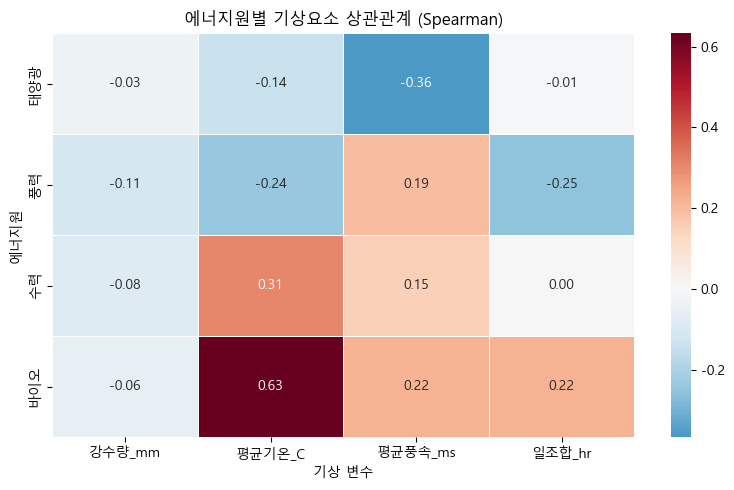

In [72]:
# Heatmap 시각화
import seaborn as sns

# ✅ 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')   # 윈도우: 맑은 고딕
# plt.rc('font', family='NanumGothic')   # 리눅스/맥: 나눔고딕 설치 시 사용
plt.rcParams['axes.unicode_minus'] = False  # 음수 기호 깨짐 방지


plt.figure(figsize=(8, 5))

sns.heatmap(
    energy_weather_corr,
    annot=True,          # 숫자 표시
    fmt=".2f",           # 소수점 2자리
    cmap="RdBu_r",       # 음(-) → 파랑 / 양(+) → 빨강
    center=0,            # 0 기준 색상 분리
    linewidths=0.5
)

plt.title("에너지원별 기상요소 상관관계 (Spearman)")
plt.ylabel("에너지원")
plt.xlabel("기상 변수")
plt.tight_layout()
plt.show()

In [73]:
#정책 시행 전후 비교하기 위해 연도별 영향 차이 비교

analysis_df.groupby("연도")[energy_cols + weather_cols] \
           .corr(method="spearman") \
           .loc[:, weather_cols]

강수량_mm    평균기온_C   평균풍속_ms    일조합_hr
연도                                                  
2020 태양광     -0.128509 -0.069425 -0.485972 -0.072379
     풍력      -0.118732 -0.263678  0.183495 -0.186579
     수력      -0.277377  0.247390  0.199411 -0.091459
     바이오     -0.201145  0.445392  0.190369  0.079021
     강수량_mm   1.000000  0.299703  0.406528  0.614243
     평균기온_C   0.299703  1.000000  0.240356  0.299703
     평균풍속_ms  0.406528  0.240356  1.000000  0.510386
     일조합_hr   0.614243  0.299703  0.510386  1.000000
2021 태양광     -0.290993 -0.184640 -0.385410 -0.025111
     풍력       0.049478 -0.229398  0.177407 -0.313361
     수력       0.167925  0.374833  0.145565 -0.008996
     바이오      0.555876  0.691662  0.158780  0.167187
     강수량_mm   1.000000  0.664688  0.391623  0.356083
     평균기온_C   0.664688  1.000000  0.253579  0.338279
     평균풍속_ms  0.391623  0.253579  1.000000  0.520663
     일조합_hr   0.356083  0.338279  0.520663  1.000000
2022 태양광      0.296901 -0.214182 -0.303034  0.113738
     풍력      -0.502277 -0.250389  0.229568 -0.205409
     수력       0.059973  0.338849  0.226567 -0.122945
     바이오     -0.151911  0.691662  0.303199  0.097597
     강수량_mm   1.000000 -0.014837 -0.289532  0.207715
     평균기온_C  -0.014837  1.000000  0.322198  0.222552
     평균풍속_ms -0.289532  0.322198  1.000000  0.500371
     일조합_hr   0.207715  0.222552  0.500371  1.000000
2023 태양광     -0.270313 -0.229124 -0.301755  0.039882
     풍력       0.028274 -0.219658  0.191880 -0.336311
     수력      -0.202410  0.342102  0.131918  0.343347
     바이오     -0.089110  0.717655  0.289237  0.577941
     강수량_mm   1.000000  0.253898  0.031510  0.210682
     평균기온_C   0.253898  1.000000  0.295812  0.660728
     평균풍속_ms  0.031510  0.295812  1.000000  0.343608
     일조합_hr   0.210682  0.660728  0.343608  1.000000

In [74]:
#강원도 행정구역 단위의 연간 기상요소와 신재생에너지 발전량 간 상관관계를 분석했다.

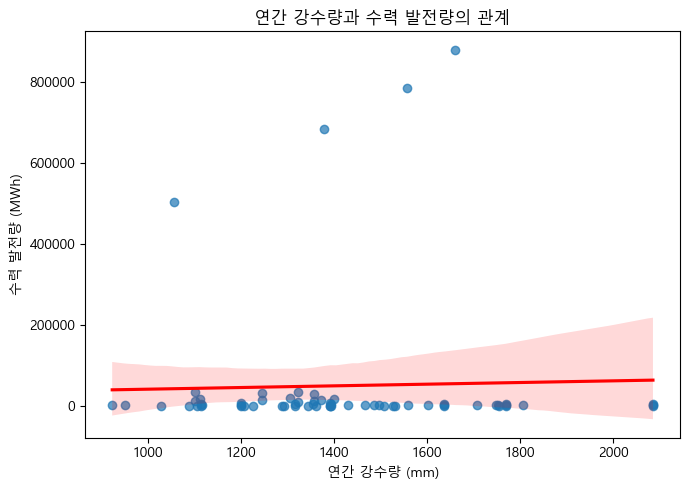

In [78]:
#수력 강수량 관련 산점도 추세선
plt.figure(figsize=(7, 5))

sns.regplot(
    data=analysis_df,
    x="강수량_mm",
    y="수력",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"}
)

plt.title("연간 강수량과 수력 발전량의 관계")
plt.xlabel("연간 강수량 (mm)")
plt.ylabel("수력 발전량 (MWh)")
plt.tight_layout()
plt.show()

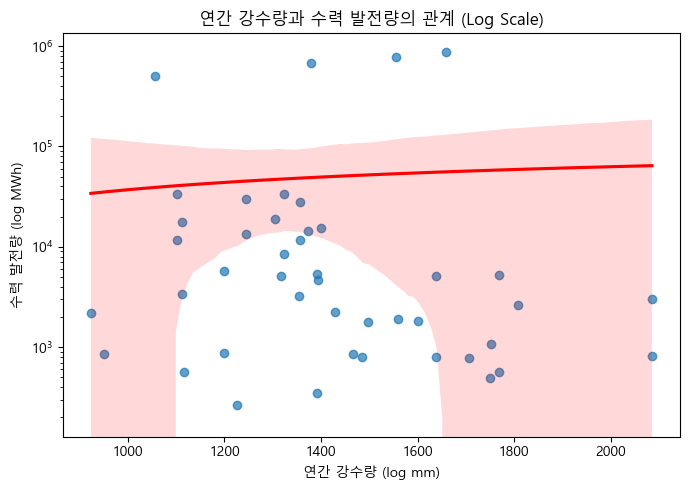

In [ ]:
# 강수량 수력 발전을 로그스케일 시도
plt.figure(figsize=(7, 5))

sns.regplot(
    data=analysis_df,
    x="강수량_mm",
    y="수력",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"},
    logx=True          # x축 로그
)

plt.yscale("log")     # y축 로그

plt.title("연간 강수량과 수력 발전량의 관계 (Log Scale)")
plt.xlabel("연간 강수량 (log mm)")
plt.ylabel("수력 발전량 (log MWh)")
plt.tight_layout()
plt.show()

#값 범위가 큰 데이터를 로그스케일로 압축해 알아보기 쉽도록 했다. 

In [76]:
# 강수량 산점도+ 추세선 코드 기반으로 함수 생성
def energy_weather_scatter(df, energy, weather):
    plt.figure(figsize=(6, 4))
    sns.regplot(
        data=df,
        x=weather,
        y=energy,
        scatter_kws={"alpha": 0.6},
        line_kws={"color": "red"}
    )
    plt.title(f"{weather} vs {energy}")
    plt.xlabel(weather)
    plt.ylabel(energy)
    plt.tight_layout()
    plt.show()

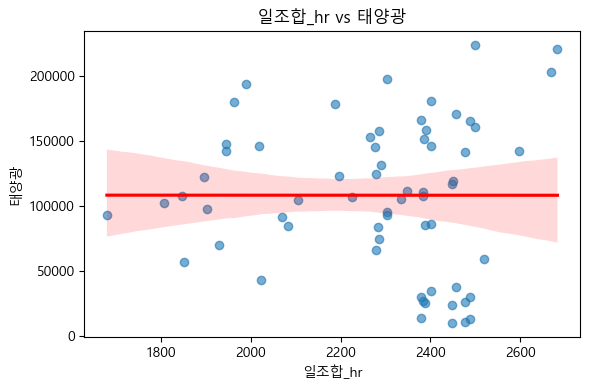

In [ ]:
#실적용
energy_weather_scatter(analysis_df, "태양광", "일조합_hr")


In [ ]:
#상관관계 분석 위해 pip install scipy 설치 

In [84]:
#수력 강수량 변수값 생성
yearly_corr = (
    analysis_df
    .groupby("연도")
    .apply(lambda x: x["수력"].corr(x["강수량_mm"], method="spearman"))
    .reset_index(name="spearman_corr")
)

yearly_corr

#연도별 변화 시각화 (선 그래프)

plt.figure(figsize=(7, 4))

plt.plot(
    yearly_corr["연도"],
    yearly_corr["spearman_corr"],
    marker="o"
)

plt.axhline(0, color="gray", linestyle="--", alpha=0.6)

plt.title("연도별 강수량-수력 발전 상관계수 변화")
plt.xlabel("연도")
plt.ylabel("Spearman 상관계수")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 